# Stage 5 — Complete asynchronous feature tracker

This single-pair experiment composes APS Shi–Tomasi initialization, fixed-capacity FeatureState memory, stable chronological event processing with Stage 4A brute-force association, Stage 4B alpha-beta updates, prediction at the next APS timestamp, and comparison against next-frame Shi–Tomasi detections. Endpoint EPE uses successful one-to-one greedy nearest matches within a configured radius. Unmatched predicted features count toward failure rate but not EPE. Track lifetime is interval-censored to this one APS pair. No KLT, VIO, SNN, FPGA, HLS, RTL, SLAM, Kalman filter, or grid hashing is included.

In [1]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "asynchronous_feature_tracker.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.asynchronous_feature_tracker as asynchronous_feature_tracker
asynchronous_feature_tracker = importlib.reload(asynchronous_feature_tracker)

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
interval_index = min(678, len(windows) - 1)
window = windows.get_window(interval_index)
config = asynchronous_feature_tracker.TrackerConfig(
    feature_count=500,
    slot_count=500,
    radius_px=8,
    time_window_us=50_000,
    alpha=0.5,
    beta=0.1,
    minimum_delta_t_us=1,
    confidence_penalty=0.05,
    reference_match_radius_px=15,
)
result = asynchronous_feature_tracker.evaluate_frame_pair(window, config)
outputs = asynchronous_feature_tracker.save_experiment(
    window, result, config, asynchronous_feature_tracker.DEFAULT_OUTPUT_DIR
)
dict(result.diagnostics), dict(result.stage_pass), outputs

({'events_processed': 10879,
  'successful_updates': 1555,
  'events_rejected': 9324,
  'events_ambiguous': 576,
  'association_ratio': 0.14293593161136134,
  'active_features_initial': 500,
  'active_features_final': 500,
  'features_with_updates': 132,
  'mean_events_per_updated_feature': 11.780303030303031,
  'max_events_per_feature': 44,
  'mean_position_update_magnitude': 2.0297855867984143,
  'max_position_update_magnitude': 3.994744274315267,
  'mean_velocity_update_magnitude': 0.011447682836172555,
  'max_velocity_update_magnitude': 0.5458268078536216,
  'aps_frame_k_features_detected': 500,
  'aps_frame_k_plus_1_reference_features_detected': 500,
  'active_features_at_frame_k_plus_1': 500,
  'successfully_predicted_features': 354,
  'predicted_features_evaluated': 500,
  'epe_px': 3.950199531600926,
  'epe_median_px': 3.0,
  'failure_rate': 0.292,
  'track_lifetime_mean_us': 44066.0,
  'track_lifetime_max_us': 44066,
  'events_per_successful_feature_update': 6.996141479099679,

# Stage 5 — Complete asynchronous feature tracker

- APS pair: 678 → 679
- Common-axis interval: [29895515, 29939581) μs
- Initial features: 500
- Events processed: 10879
- Successful asynchronous updates: 1555
- Events rejected: 9324
- Active features at t(k+1): 500
- Successfully predicted/reference-matched features: 354
- Endpoint EPE (matched features only): 3.9502 px
- Failure rate: 0.292
- Mean track lifetime: 44066 μs
- Events per successful feature update: 6.99614
- Total processing time: 11965.657 ms
- Event-loop time: 11605.979 ms
- Per-event update-loop latency mean / median / p95: 1065.335 / 1009.266 / 1505.792 μs

## Stage checks

| Component | Result |
|---|---|
| Event processing | PASS |
| Association | PASS |
| State update | PASS |
| Prediction | PASS |
| Frame-to-frame evaluation | PASS |

EPE is the mean Euclidean pixel error over successful, one-to-one greedy matches from predicted states to frame-k+1 Shi-Tomasi detections within the configured match radius. Unmatched predicted states are counted as failures, not included in EPE.

Track lifetime is interval-censored: because this experiment evaluates one frame pair and does not invalidate tracks, every initialized valid feature is counted for the full APS interval. Events per successful update is total processed events divided by successful state updates.

This is an algorithm-validation baseline, not a tracking-quality conclusion. No KLT, VIO, SNN, FPGA, HLS, RTL, SLAM, grid hashing, or Kalman filtering is included.


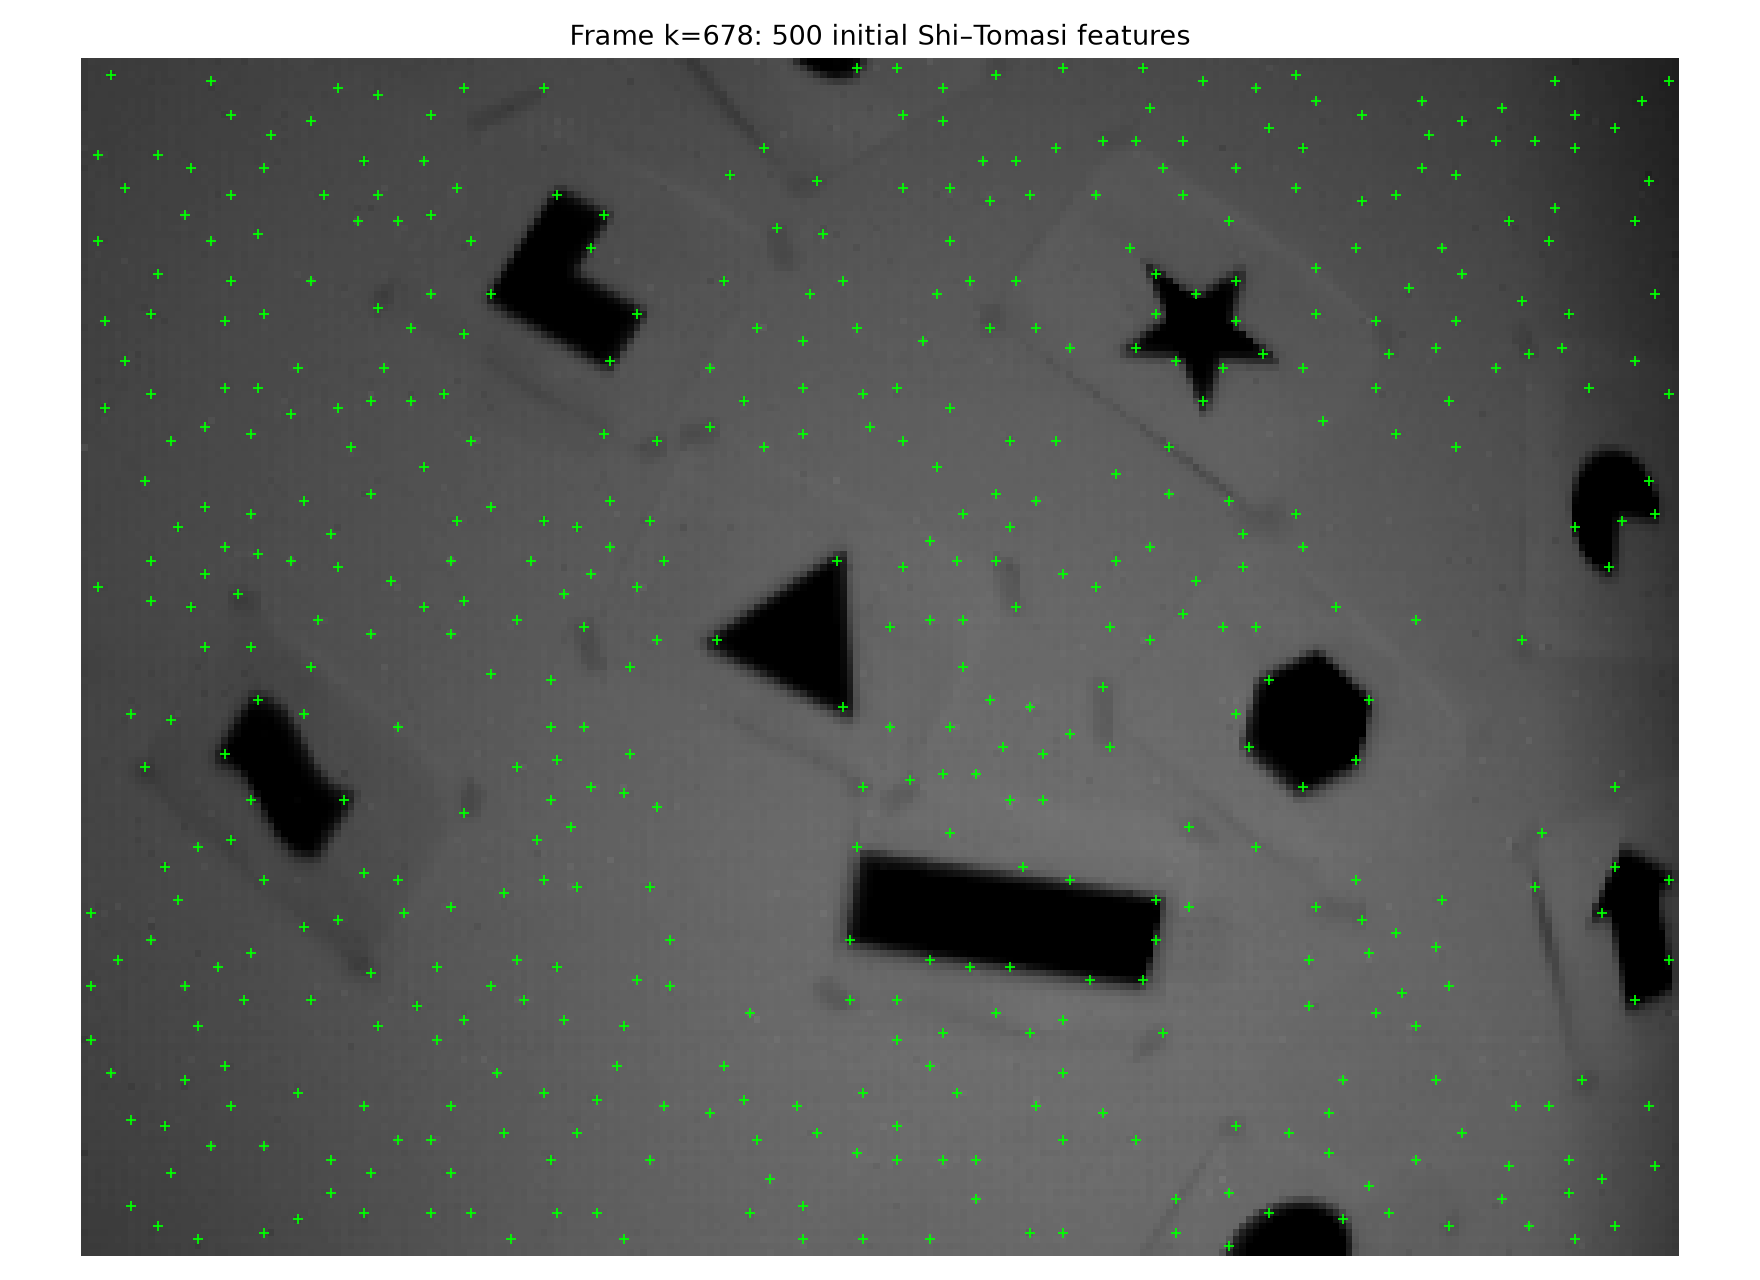

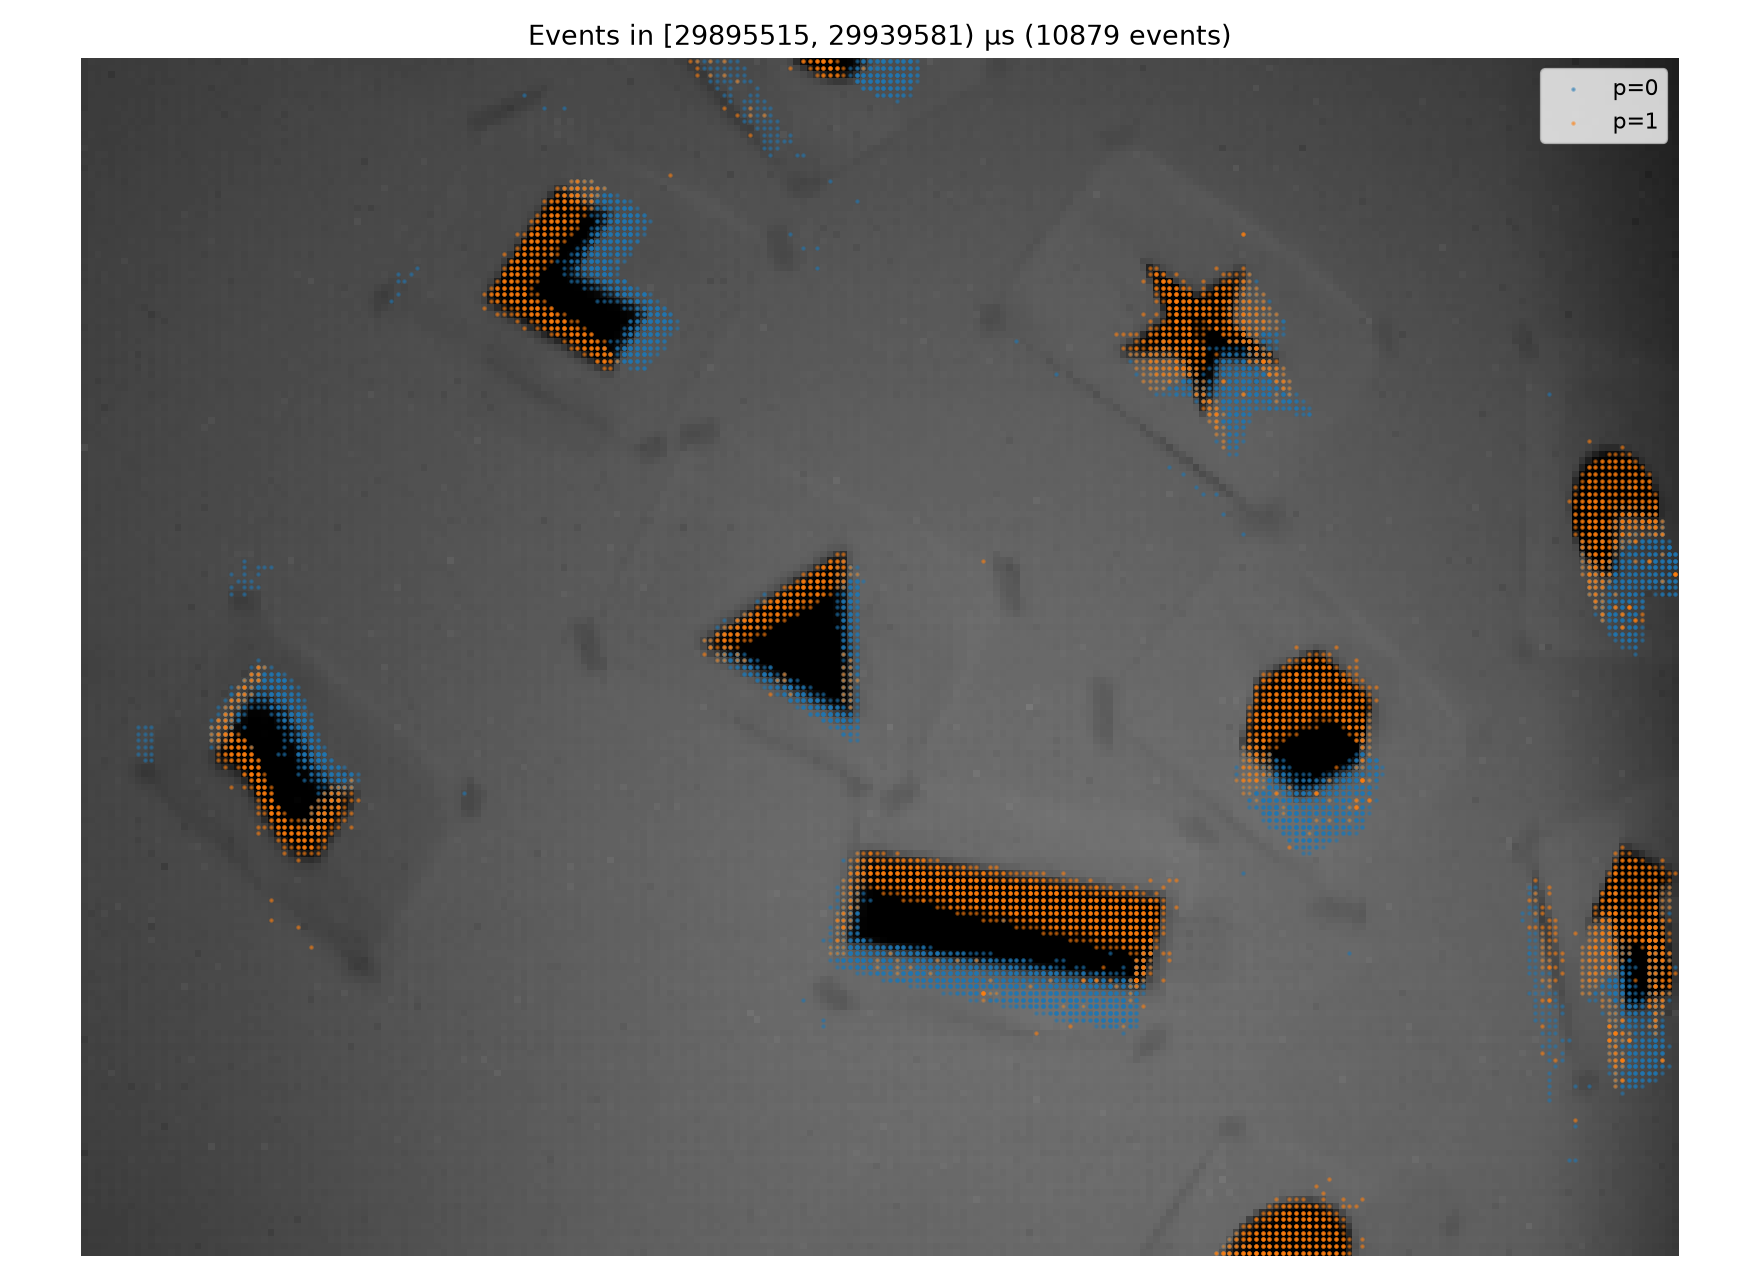

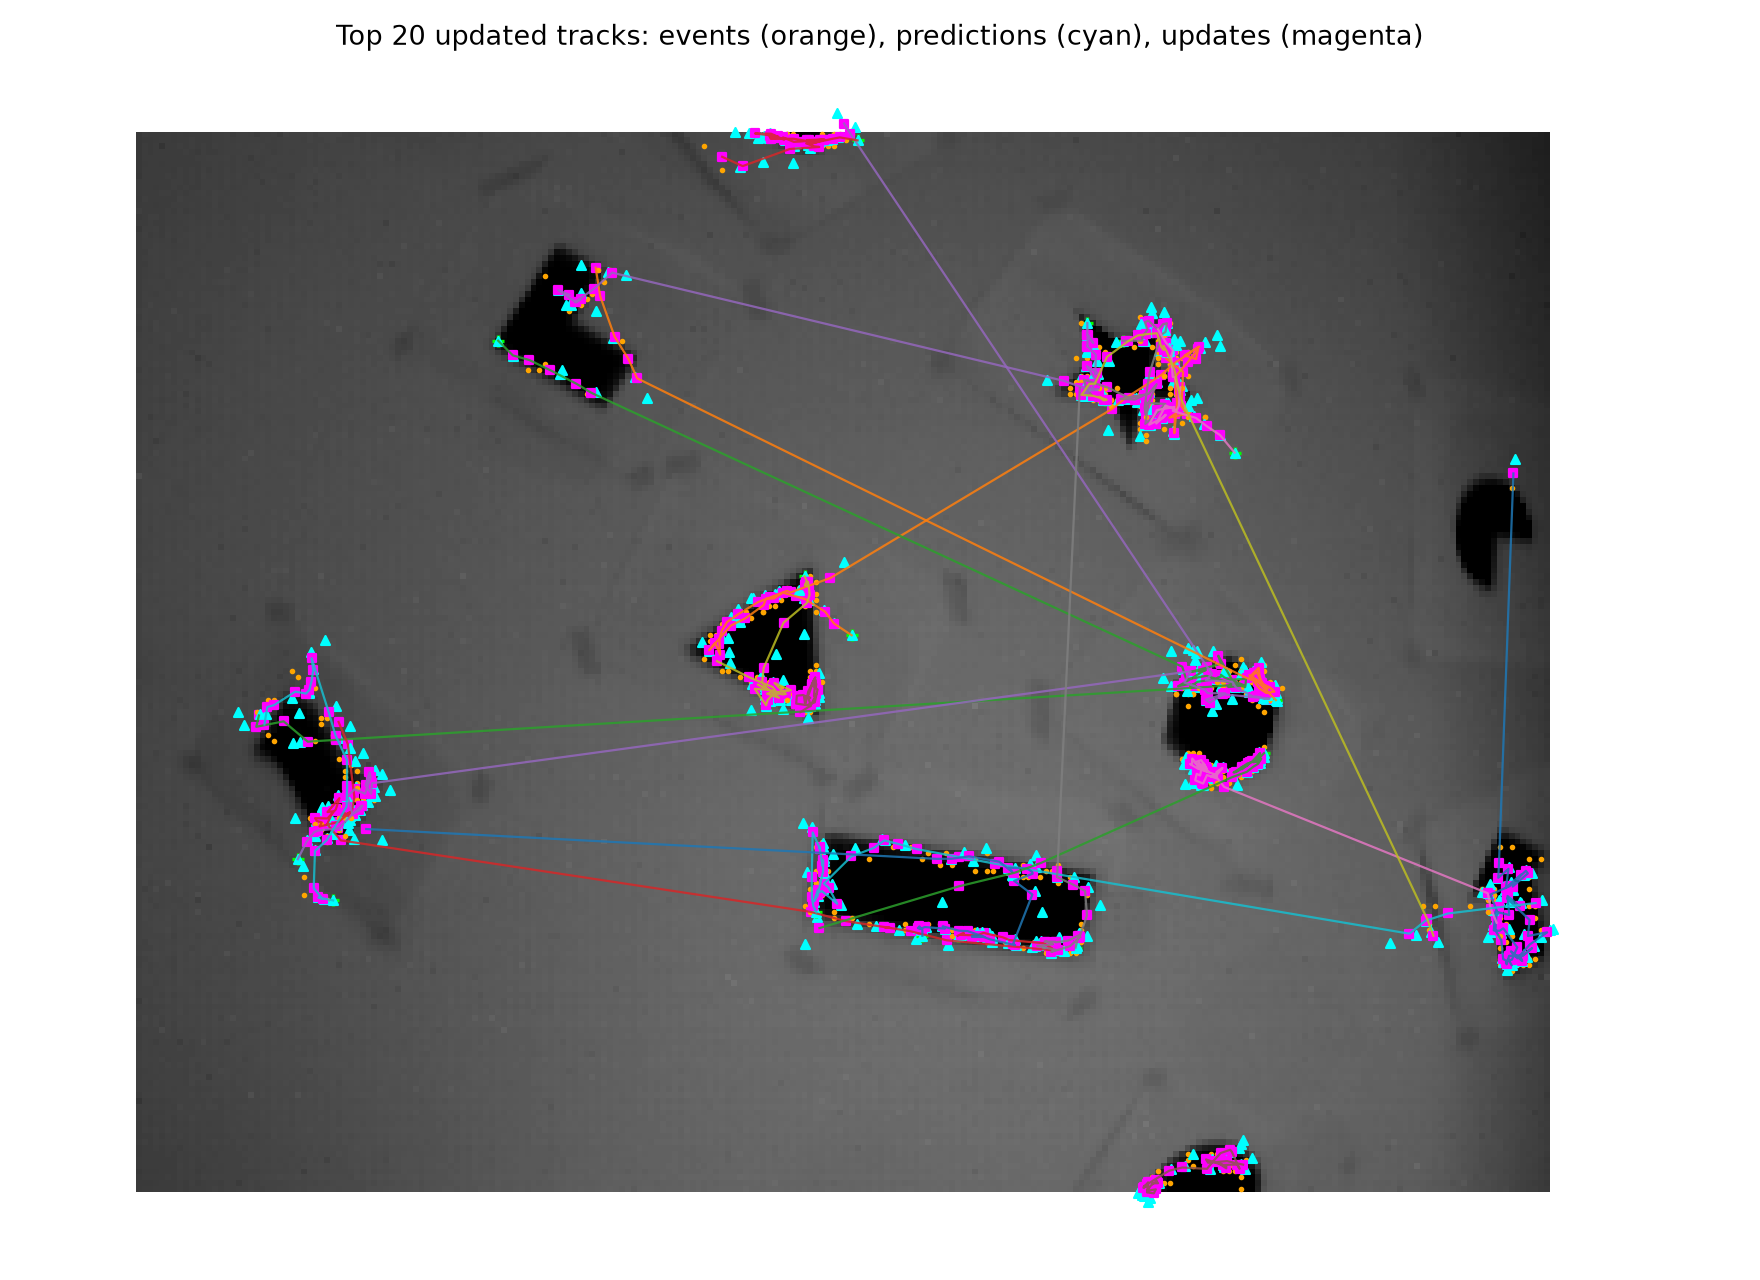

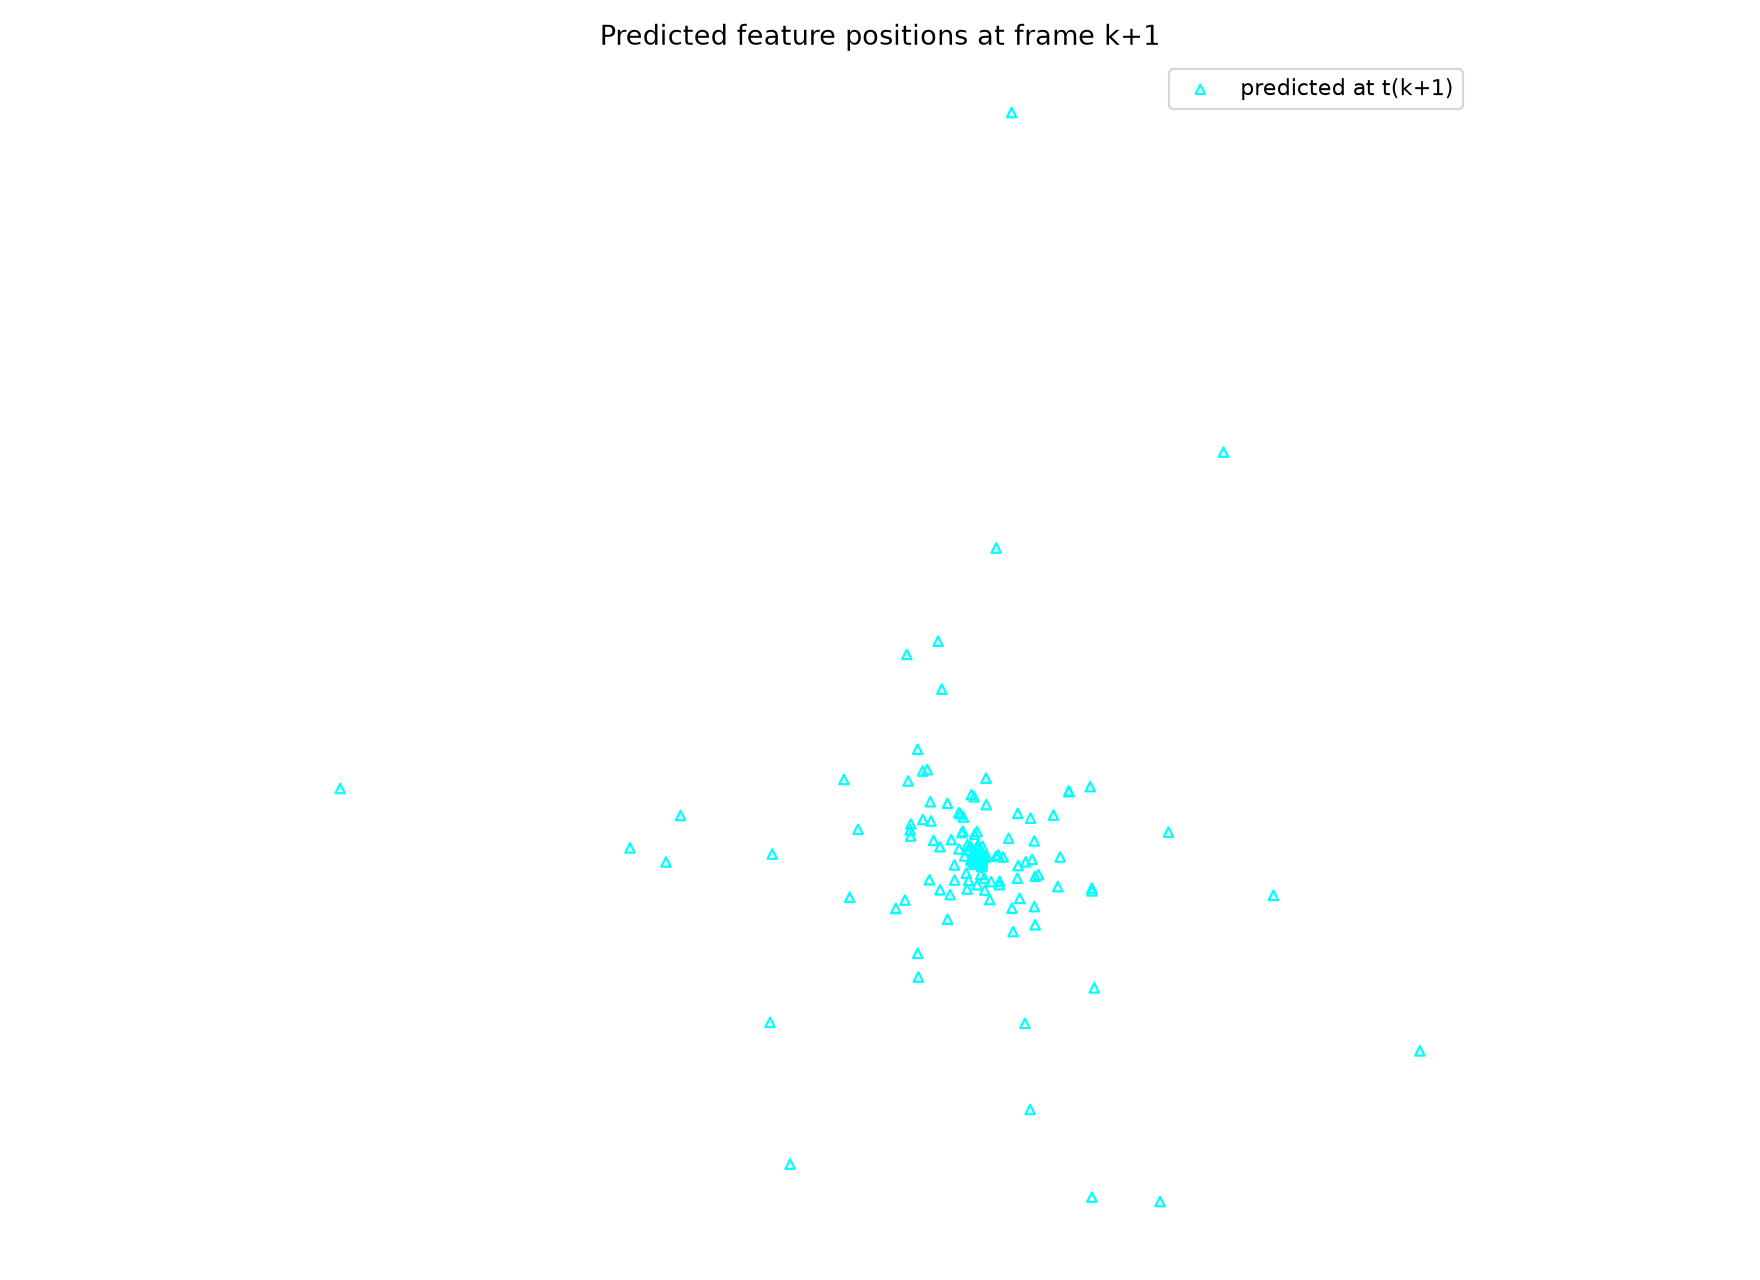

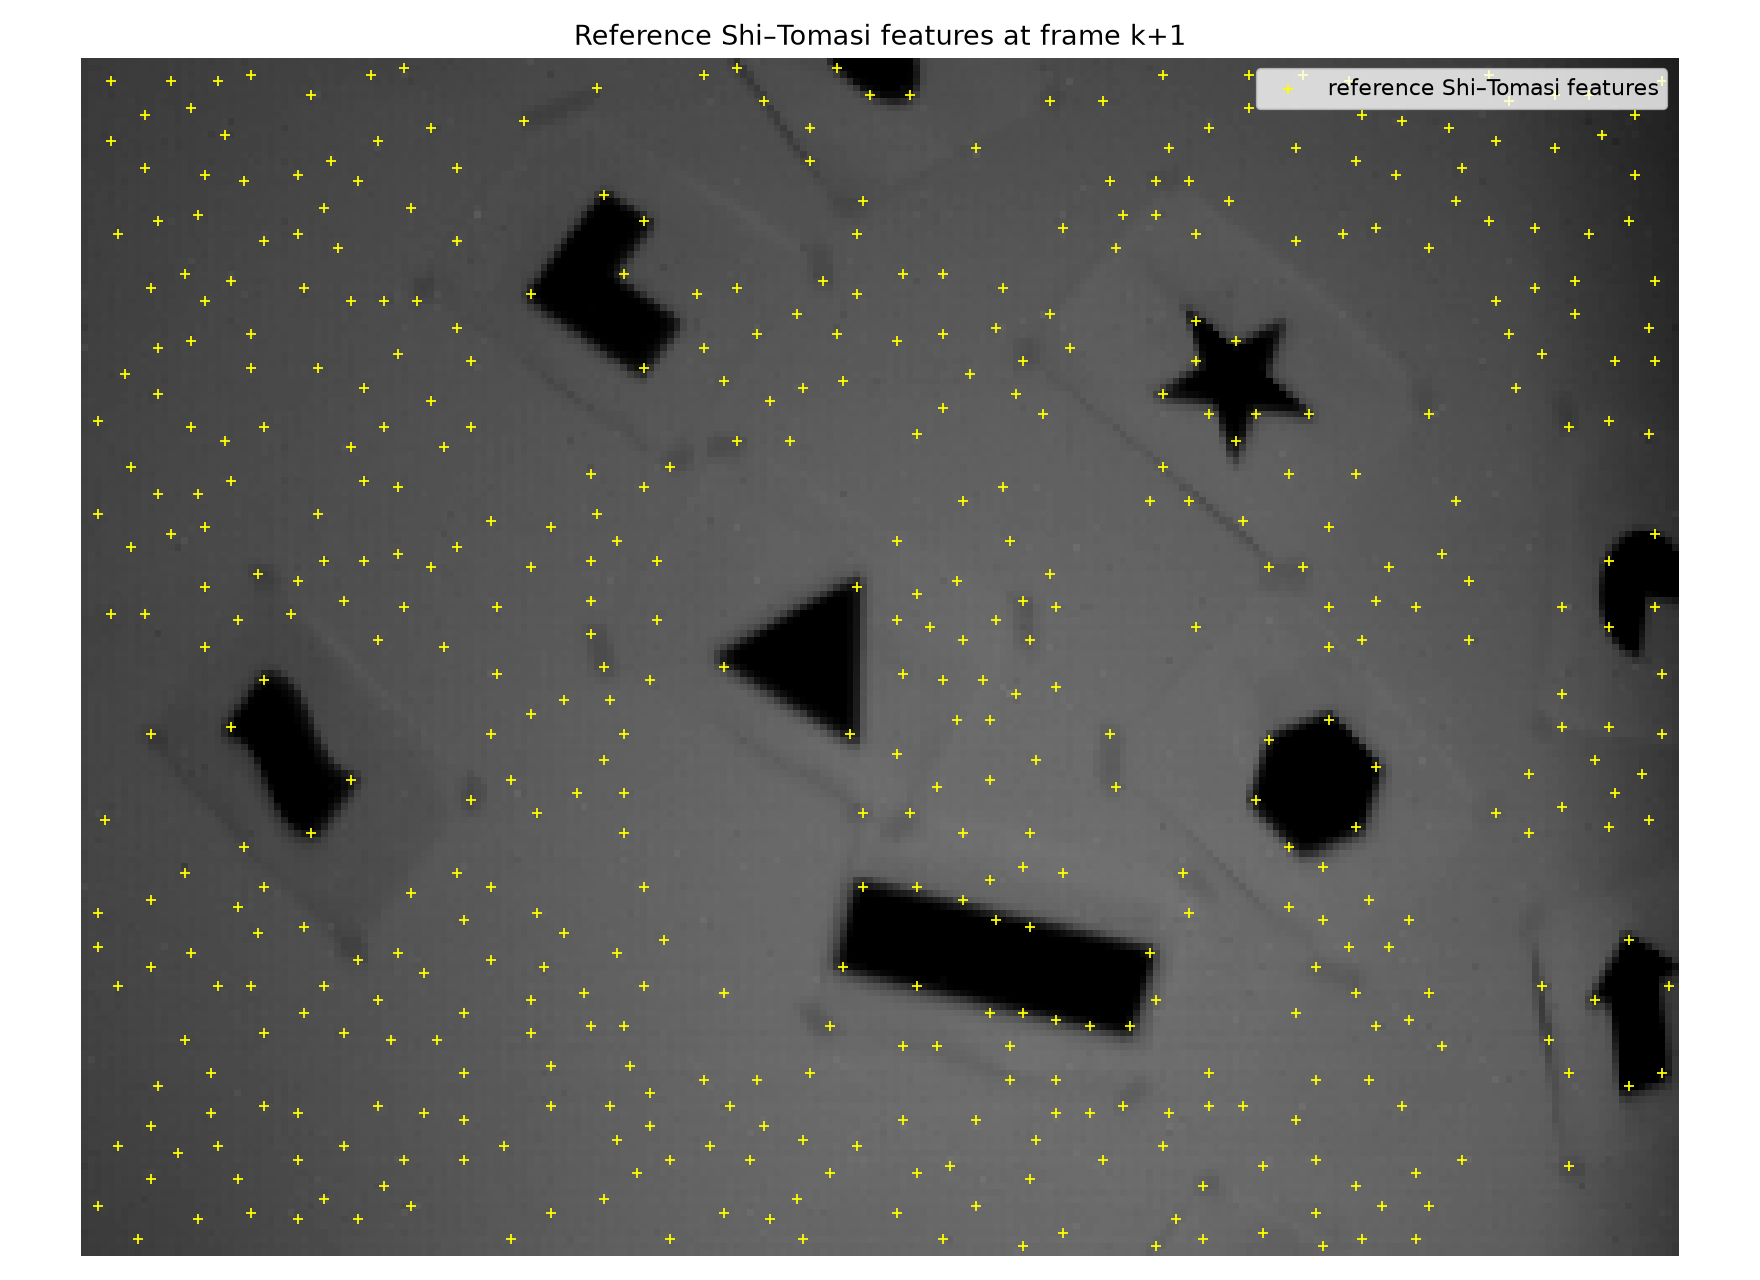

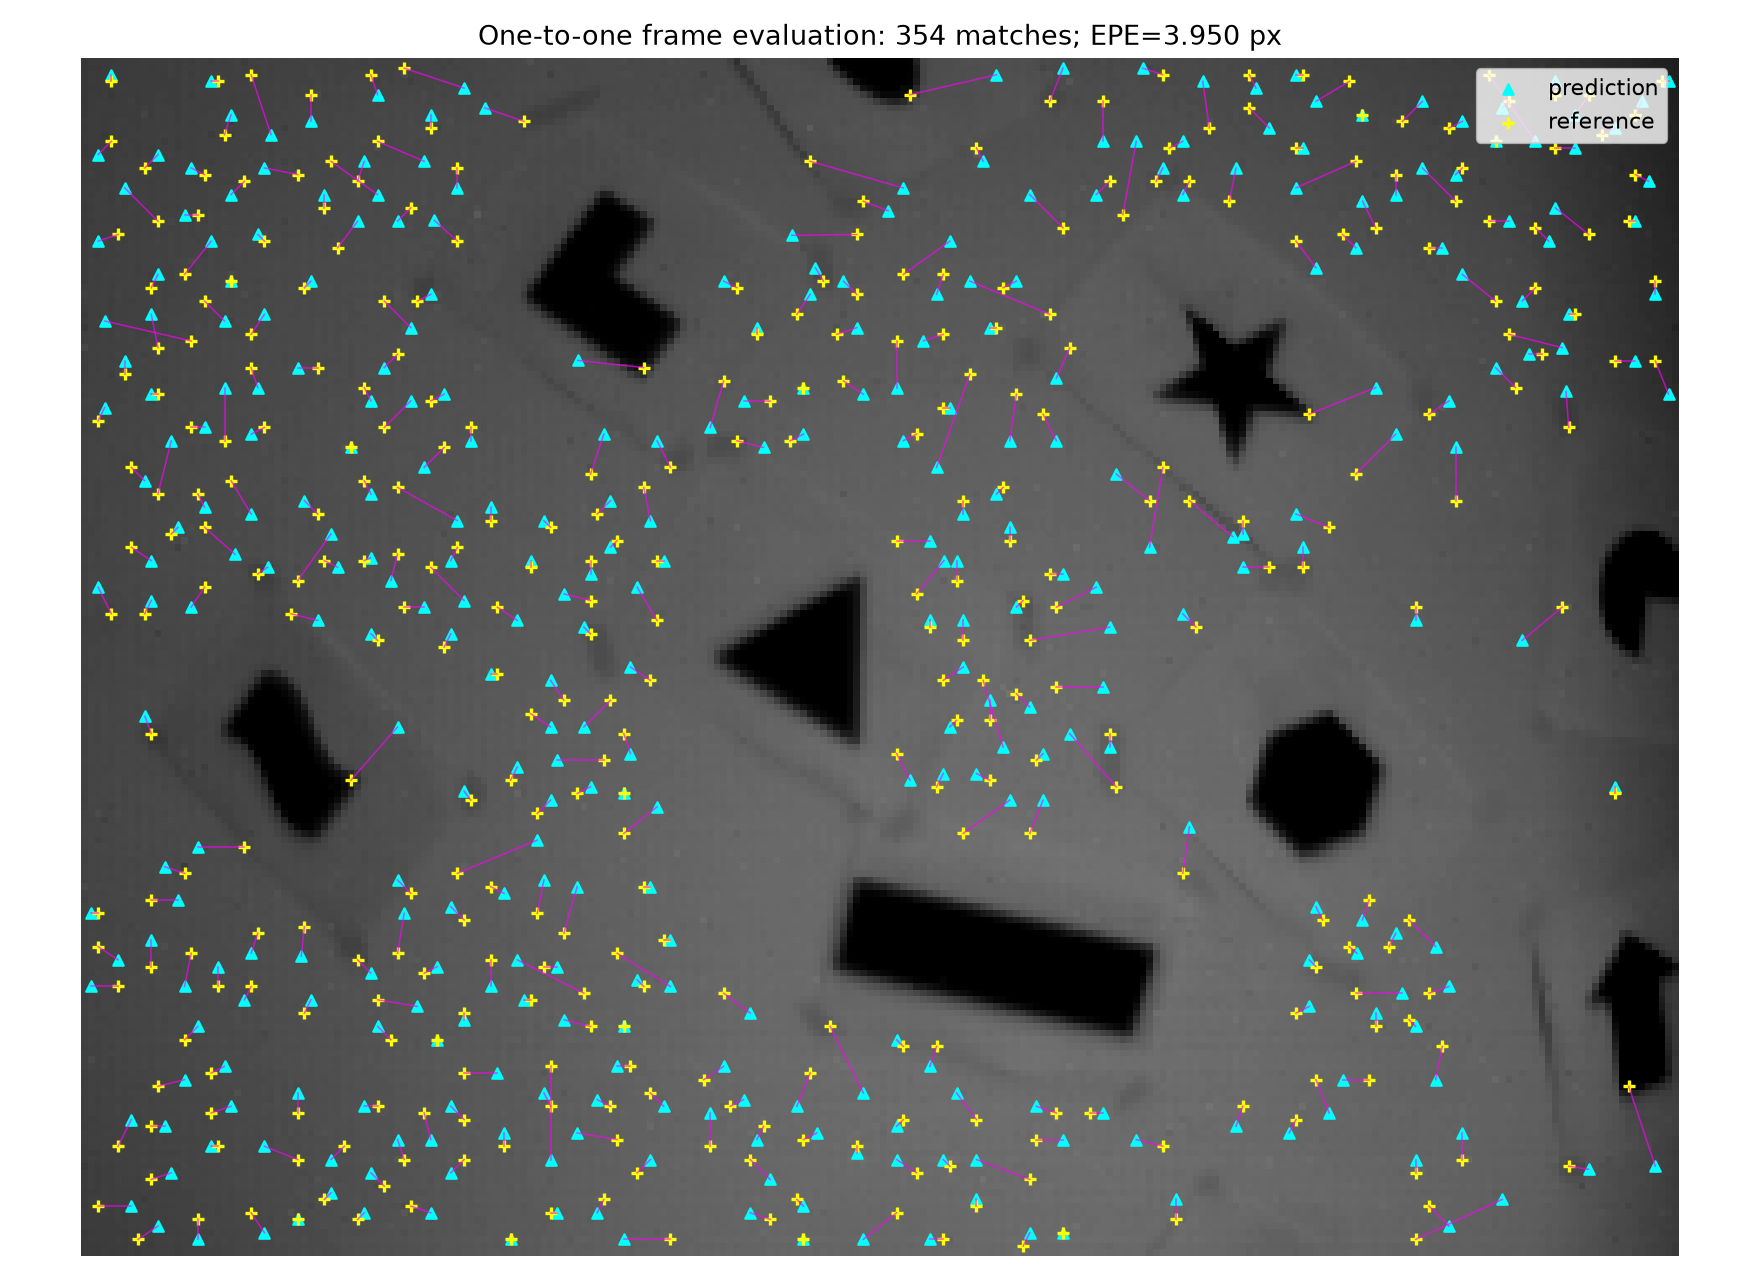

In [2]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
for name in sorted(key for key in outputs if key.startswith(("01_", "02_", "03_", "04_", "05_", "06_"))):
    display(Image(filename=str(outputs[name])))